# Step 5: Critical Thinking, Ethical AI, and Bias Auditing

This notebook evaluates the final LightGBM future-purchase prediction model from an ethical AI and responsible machine learning perspective.

The scope of this step includes:

1. Reviewing model explainability  
2. Auditing prediction behavior across available customer-session segments  
3. Checking for possible proxy bias and uneven model performance  
4. Documenting limitations, leakage controls, overfitting concerns, and generalization risks  
5. Proposing mitigation strategies  
6. Preparing a Bias & Fairness Analysis section for the final report  

The dataset does not contain direct sensitive demographic attributes such as gender, race, age, religion, disability status, or socioeconomic status. Therefore, formal demographic fairness testing is not possible. Instead, this notebook performs segment-level audits using available non-sensitive features such as product category, brand, price band, time of session, and early-session behavior.

# Import Libraries and Configure Project Paths

In [1]:
from pathlib import Path
import json
import platform
import sys
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import display

import sklearn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

RANDOM_STATE = 42

# Locate project root whether notebook is run from project_folder/
# or from project_folder/notebooks/
current_folder = Path.cwd().resolve()

possible_project_roots = [
    current_folder,
    current_folder.parent
]

PROJECT_ROOT = next(
    (
        folder
        for folder in possible_project_roots
        if (folder / "data" / "processed").exists()
        and (folder / "models").exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate project root. Expected folders were not found:\n"
        "data/processed and models\n\n"
        "Please confirm that this notebook is inside project_folder/notebooks/"
        " or project_folder/."
    )

PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"
MODELS_FOLDER = PROJECT_ROOT / "models"
REPORTS_FOLDER = PROJECT_ROOT / "reports"

MODEL_READY_DATA_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_modeling_dataset_ready_for_split.csv"
)

FEATURE_INVENTORY_PATH = (
    PROCESSED_DATA_FOLDER
    / "leakage_safe_feature_inventory_with_selection_status.csv"
)

FINAL_TEST_PREDICTIONS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_test_predictions.csv"
)

FINAL_MODEL_METADATA_PATH = (
    MODELS_FOLDER
    / "step4_final_lightgbm_model_metadata.json"
)

FINAL_MODEL_PIPELINE_PATH = (
    MODELS_FOLDER
    / "step4_final_lightgbm_purchase_propensity_pipeline.joblib"
)

FINAL_RAW_FEATURE_IMPORTANCE_PATH = (
    PROCESSED_DATA_FOLDER
    / "step4_final_lightgbm_raw_feature_importance.csv"
)

for path in [
    MODEL_READY_DATA_PATH,
    FEATURE_INVENTORY_PATH,
    FINAL_TEST_PREDICTIONS_PATH,
    FINAL_MODEL_METADATA_PATH,
    FINAL_MODEL_PIPELINE_PATH,
    FINAL_RAW_FEATURE_IMPORTANCE_PATH
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required Step 3/Step 4 artifact not found:\n{path}"
        )

print(f"Project root: {PROJECT_ROOT}")
print(f"Model-ready dataset: {MODEL_READY_DATA_PATH}")
print(f"Final model pipeline: {FINAL_MODEL_PIPELINE_PATH}")
print(f"Final model metadata: {FINAL_MODEL_METADATA_PATH}")
print(f"Final test predictions: {FINAL_TEST_PREDICTIONS_PATH}")
print(f"Python version: {sys.version.split()[0]}")
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Operating system: {platform.system()} {platform.release()}")

Project root: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder
Model-ready dataset: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\leakage_safe_modeling_dataset_ready_for_split.csv
Final model pipeline: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\models\step4_final_lightgbm_purchase_propensity_pipeline.joblib
Final model metadata: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\models\step4_final_lightgbm_model_metadata.json
Final test predictions: C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step4_final_lightgbm_test_predictions.csv
Python version: 3.14.5
pandas version: 3.0.3
scikit-learn version: 1.9.0
Operating system: Windows 11


# Load Final Model, Metadata, Predictions, and Test Data

In [2]:
# Load model-ready dataset from Step 3.
model_ready_data = pd.read_csv(MODEL_READY_DATA_PATH)

# Load feature inventory from Step 3.
feature_inventory = pd.read_csv(FEATURE_INVENTORY_PATH)

# Load final Step 4 test predictions.
final_test_predictions = pd.read_csv(FINAL_TEST_PREDICTIONS_PATH)

# Load final model metadata.
with open(FINAL_MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
    final_model_metadata = json.load(file)

# Load final trained pipeline.
final_model_pipeline = joblib.load(FINAL_MODEL_PIPELINE_PATH)

# Load raw feature importance.
final_raw_feature_importance = pd.read_csv(FINAL_RAW_FEATURE_IMPORTANCE_PATH)

TARGET_COLUMN = "future_purchase"
TIME_COLUMN = "first_event_time"
SESSION_COLUMN = "user_session"
PREDICTION_COLUMN = "predicted_future_purchase"
PROBABILITY_COLUMN = "predicted_probability"

# Restore date type.
model_ready_data[TIME_COLUMN] = pd.to_datetime(
    model_ready_data[TIME_COLUMN],
    errors="coerce",
    utc=True
)

final_test_predictions[TIME_COLUMN] = pd.to_datetime(
    final_test_predictions[TIME_COLUMN],
    errors="coerce",
    utc=True
)

# Recreate test audit dataset by merging predictions with model-ready features.
test_audit_data = final_test_predictions.merge(
    model_ready_data,
    on=[SESSION_COLUMN, TIME_COLUMN, TARGET_COLUMN],
    how="left",
    validate="one_to_one"
)

if test_audit_data.isna().all(axis=1).any():
    raise ValueError("Unexpected empty rows were found after merging test data.")

if test_audit_data[SESSION_COLUMN].duplicated().any():
    raise ValueError("Duplicate sessions found in test audit data.")

if test_audit_data[PROBABILITY_COLUMN].isna().any():
    raise ValueError("Missing predicted probabilities found.")

if test_audit_data[PREDICTION_COLUMN].isna().any():
    raise ValueError("Missing predicted labels found.")

loaded_artifact_summary = pd.DataFrame({
    "artifact": [
        "Model-ready dataset",
        "Feature inventory",
        "Final test predictions",
        "Final model metadata",
        "Final trained model pipeline",
        "Final raw feature importance",
        "Merged test audit dataset"
    ],
    "rows_or_status": [
        f"{len(model_ready_data):,} rows",
        f"{len(feature_inventory):,} rows",
        f"{len(final_test_predictions):,} rows",
        "Loaded",
        "Loaded",
        f"{len(final_raw_feature_importance):,} rows",
        f"{len(test_audit_data):,} rows"
    ]
})

print("Loaded Step 5 Inputs")
display(loaded_artifact_summary)

print("Final Model Metadata Summary")
display(pd.DataFrame({
    "metadata_field": [
        "model_name",
        "algorithm",
        "target_variable",
        "prediction_time",
        "selected_probability_threshold",
        "selection_metric",
        "test_pr_auc",
        "test_roc_auc",
        "test_precision",
        "test_recall",
        "test_f1_score"
    ],
    "value": [
        final_model_metadata.get("model_name"),
        final_model_metadata.get("algorithm"),
        final_model_metadata.get("target_variable"),
        final_model_metadata.get("prediction_time"),
        final_model_metadata.get("selected_probability_threshold"),
        final_model_metadata.get("selection_metric"),
        final_model_metadata.get("test_pr_auc"),
        final_model_metadata.get("test_roc_auc"),
        final_model_metadata.get("test_precision"),
        final_model_metadata.get("test_recall"),
        final_model_metadata.get("test_f1_score")
    ]
}))

Loaded Step 5 Inputs


,artifact,rows_or_status
0,Model-ready dataset,"92,799 rows"
1,Feature inventory,17 rows
2,Final test predictions,"13,920 rows"
3,Final model metadata,Loaded
4,Final trained model pipeline,Loaded
5,Final raw feature importance,16 rows
6,Merged test audit dataset,"13,920 rows"


Final Model Metadata Summary


,metadata_field,value
0,model_name,LightGBM
1,algorithm,LightGBM LGBMClassifier
2,target_variable,future_purchase
3,prediction_time,After first two session events
4,selected_probability_threshold,0.65
5,selection_metric,Validation PR-AUC / Average Precision
6,test_pr_auc,0.482408
7,test_roc_auc,0.78018
8,test_precision,0.613835
9,test_recall,0.489555


# Sensitive Attribute Availability Review

In [3]:
# Step 5 fairness review begins by checking whether protected attributes exist.
sensitive_attributes_to_check = [
    "gender",
    "sex",
    "race",
    "ethnicity",
    "age",
    "date_of_birth",
    "birthdate",
    "religion",
    "disability",
    "marital_status",
    "income",
    "salary",
    "socioeconomic_status",
    "location",
    "city",
    "country"
]

available_columns_lower = {
    column.lower(): column
    for column in test_audit_data.columns
}

sensitive_attribute_review = pd.DataFrame({
    "sensitive_or_demographic_attribute": sensitive_attributes_to_check,
    "available_in_dataset": [
        attribute in available_columns_lower
        for attribute in sensitive_attributes_to_check
    ],
    "matched_column_name": [
        available_columns_lower.get(attribute, "Not available")
        for attribute in sensitive_attributes_to_check
    ]
})

direct_sensitive_attributes_available = (
    sensitive_attribute_review["available_in_dataset"].any()
)

proxy_audit_groups = [
    "category_code_clean_first",
    "category_code_clean_second",
    "brand_clean_first",
    "brand_clean_second",
    "first_event_hour",
    "first_event_dayofweek",
    "first_event_is_weekend",
    "early_cart_count",
    "early_event_gap_log1p",
    "price_for_aggregation_first",
    "price_for_aggregation_second"
]

proxy_audit_groups_available = [
    column
    for column in proxy_audit_groups
    if column in test_audit_data.columns
]

fairness_scope_summary = pd.DataFrame({
    "review_area": [
        "Direct demographic fairness audit",
        "Reason direct demographic audit is limited",
        "Proxy or segment-level audit",
        "Available segment/proxy fields"
    ],
    "assessment": [
        (
            "Possible"
            if direct_sensitive_attributes_available
            else "Not possible with current dataset"
        ),
        (
            "At least one demographic field is available."
            if direct_sensitive_attributes_available
            else (
                "The dataset does not contain direct sensitive attributes "
                "such as gender, race, age, or income."
            )
        ),
        "Will be performed using available non-sensitive session/product/time features.",
        ", ".join(proxy_audit_groups_available)
    ]
})

print("Sensitive Attribute Availability Review")
display(sensitive_attribute_review)

print("Fairness Audit Scope Summary")
display(fairness_scope_summary)

Sensitive Attribute Availability Review


,sensitive_or_demographic_attribute,available_in_dataset,matched_column_name
0,gender,False,Not available
1,sex,False,Not available
2,race,False,Not available
3,ethnicity,False,Not available
4,age,False,Not available
5,date_of_birth,False,Not available
6,birthdate,False,Not available
7,religion,False,Not available
8,disability,False,Not available
9,marital_status,False,Not available


Fairness Audit Scope Summary


,review_area,assessment
0,Direct demographic fairness audit,Not possible with current dataset
1,Reason direct demographic audit is limited,The dataset does not contain direct sensitive ...
2,Proxy or segment-level audit,Will be performed using available non-sensitiv...
3,Available segment/proxy fields,"category_code_clean_first, category_code_clean..."


### Sensitive Attribute Availability Review

The dataset does not contain direct sensitive demographic attributes such as gender, race, ethnicity, age, religion, disability status, income, or socioeconomic status. Therefore, formal demographic fairness metrics such as demographic parity, equalized odds, or disparate impact across protected demographic groups cannot be calculated directly.

To still perform a responsible AI audit, this notebook evaluates model behavior across available non-sensitive business and behavioral segments. These include product category, brand, price bands, time-of-day, day-of-week, weekend status, early cart count, and early event-gap behavior.

These segment-level audits do not prove demographic fairness, but they help identify whether the model performs unevenly across customer-session contexts.

# Overall Test Error and Ethical Risk Summary

In [4]:
# Overall Test Error and Ethical Risk Summary

y_true = test_audit_data[TARGET_COLUMN].astype("int8")
y_pred = test_audit_data[PREDICTION_COLUMN].astype("int8")
y_prob = test_audit_data[PROBABILITY_COLUMN].astype(float)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

overall_error_summary = pd.DataFrame({
    "metric": [
        "Test sessions",
        "Actual future-purchase sessions",
        "Actual non-future-purchase sessions",
        "Predicted future-purchase sessions",
        "Predicted non-future-purchase sessions",
        "True positives",
        "False positives",
        "False negatives",
        "True negatives",
        "Precision",
        "Recall / True positive rate",
        "False positive rate",
        "False negative rate",
        "F1-score",
        "Accuracy",
        "Positive prediction rate",
        "Actual future-purchase rate"
    ],
    "value": [
        f"{len(test_audit_data):,}",
        f"{int(y_true.sum()):,}",
        f"{int((y_true == 0).sum()):,}",
        f"{int(y_pred.sum()):,}",
        f"{int((y_pred == 0).sum()):,}",
        f"{tp:,}",
        f"{fp:,}",
        f"{fn:,}",
        f"{tn:,}",
        f"{precision_score(y_true, y_pred, zero_division=0):.4f}",
        f"{recall_score(y_true, y_pred, zero_division=0):.4f}",
        f"{fp / (fp + tn):.4f}",
        f"{fn / (fn + tp):.4f}",
        f"{f1_score(y_true, y_pred, zero_division=0):.4f}",
        f"{accuracy_score(y_true, y_pred):.4f}",
        f"{y_pred.mean():.4f}",
        f"{y_true.mean():.4f}"
    ]
})

ethical_error_interpretation = pd.DataFrame({
    "error_type": [
        "False positive",
        "False negative"
    ],
    "meaning_in_this_project": [
        "The model flags a session as likely to purchase, but the session does not purchase later.",
        "The model does not flag a session, but the session purchases later."
    ],
    "possible_business_impact": [
        "Marketing resources, incentives, or attention may be spent on users who would not purchase.",
        "A potentially valuable future purchaser may be missed by a targeted intervention."
    ],
    "ethical_or_responsible_ai_consideration": [
        "Avoid aggressive or manipulative targeting. Use predictions to assist decisions, not to pressure customers.",
        "Avoid treating unflagged users as low-value customers. The model should not be used to deny access, service, or fair treatment."
    ]
})

print("Overall Test Error Summary")
display(overall_error_summary)

print("Ethical Interpretation of Model Errors")
display(ethical_error_interpretation)

Overall Test Error Summary


,metric,value
0,Test sessions,"13,920"
1,Actual future-purchase sessions,"1,867"
2,Actual non-future-purchase sessions,"12,053"
3,Predicted future-purchase sessions,"1,489"
4,Predicted non-future-purchase sessions,"12,431"
5,True positives,914
6,False positives,575
7,False negatives,953
8,True negatives,"11,478"
9,Precision,0.6138


Ethical Interpretation of Model Errors


,error_type,meaning_in_this_project,possible_business_impact,ethical_or_responsible_ai_consideration
0,False positive,The model flags a session as likely to purchas...,"Marketing resources, incentives, or attention ...",Avoid aggressive or manipulative targeting. Us...
1,False negative,"The model does not flag a session, but the ses...",A potentially valuable future purchaser may be...,Avoid treating unflagged users as low-value cu...


### Overall Test Error and Ethical Risk Review

The final LightGBM model was evaluated on 13,920 untouched chronological test sessions. At the selected threshold of 0.65, the model predicted 1,489 sessions as likely future purchasers, equivalent to 10.70% of the test set.

The model achieved a precision of 61.38%, meaning that most targeted sessions were actual future-purchase sessions. However, recall was 48.96%, meaning the model missed 953 actual future-purchase sessions.

From an ethical AI perspective, false positives and false negatives have different implications. False positives may lead to inefficient marketing spend or unnecessary targeting. False negatives may cause potentially valuable customers to be missed by targeted campaigns.

Because the model does not capture every future purchaser, it should not be used to classify unflagged users as low-value customers. The model is better suited as a prioritization tool for marketing or customer engagement, not as a system for denying offers, service, or fair treatment.

# Create Segment Audit Helper Functions

In [5]:
# Segment Audit Helper Functions

def safe_rate(numerator, denominator):
    """Return a safe division result."""
    if denominator == 0:
        return np.nan
    return numerator / denominator


def audit_model_by_group(
    data,
    group_column,
    min_sessions=100
):
    """
    Audit model behavior across a segment/group column.

    This is a segment-level audit, not a formal demographic fairness audit,
    unless the group column is a protected attribute.
    """
    audit_rows = []

    for group_value, group_data in data.groupby(group_column, dropna=False):
        group_y_true = group_data[TARGET_COLUMN].astype("int8")
        group_y_pred = group_data[PREDICTION_COLUMN].astype("int8")

        if len(group_data) < min_sessions:
            continue

        group_tn, group_fp, group_fn, group_tp = confusion_matrix(
            group_y_true,
            group_y_pred,
            labels=[0, 1]
        ).ravel()

        audit_rows.append({
            "group_variable": group_column,
            "group_value": group_value,
            "sessions": len(group_data),
            "actual_future_purchase_rate": group_y_true.mean(),
            "positive_prediction_rate": group_y_pred.mean(),
            "precision": precision_score(
                group_y_true,
                group_y_pred,
                zero_division=0
            ),
            "recall_true_positive_rate": recall_score(
                group_y_true,
                group_y_pred,
                zero_division=0
            ),
            "false_positive_rate": safe_rate(
                group_fp,
                group_fp + group_tn
            ),
            "false_negative_rate": safe_rate(
                group_fn,
                group_fn + group_tp
            ),
            "f1_score": f1_score(
                group_y_true,
                group_y_pred,
                zero_division=0
            ),
            "accuracy": accuracy_score(
                group_y_true,
                group_y_pred
            ),
            "true_positives": int(group_tp),
            "false_positives": int(group_fp),
            "false_negatives": int(group_fn),
            "true_negatives": int(group_tn)
        })

    audit_table = pd.DataFrame(audit_rows)

    if audit_table.empty:
        return audit_table

    audit_table["positive_prediction_rate_percent"] = (
        audit_table["positive_prediction_rate"] * 100
    )

    audit_table["actual_future_purchase_rate_percent"] = (
        audit_table["actual_future_purchase_rate"] * 100
    )

    audit_table = (
        audit_table
        .sort_values(
            ["group_variable", "sessions"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

    return audit_table


def summarize_group_audit(audit_table):
    """
    Summarize unevenness across groups using segment-level parity indicators.

    These are not formal protected-class fairness conclusions unless the
    grouping variable is a protected demographic attribute.
    """
    summary_rows = []

    for group_variable, group_data in audit_table.groupby("group_variable"):
        if len(group_data) < 2:
            continue

        max_positive_rate = group_data["positive_prediction_rate"].max()
        min_positive_rate = group_data["positive_prediction_rate"].min()

        max_recall = group_data["recall_true_positive_rate"].max()
        min_recall = group_data["recall_true_positive_rate"].min()

        max_fpr = group_data["false_positive_rate"].max()
        min_fpr = group_data["false_positive_rate"].min()

        summary_rows.append({
            "group_variable": group_variable,
            "groups_evaluated": len(group_data),
            "largest_group_sessions": int(group_data["sessions"].max()),
            "smallest_group_sessions": int(group_data["sessions"].min()),
            "min_positive_prediction_rate": min_positive_rate,
            "max_positive_prediction_rate": max_positive_rate,
            "positive_prediction_rate_gap": (
                max_positive_rate - min_positive_rate
            ),
            "selection_rate_ratio_min_to_max": safe_rate(
                min_positive_rate,
                max_positive_rate
            ),
            "recall_gap": max_recall - min_recall,
            "false_positive_rate_gap": max_fpr - min_fpr,
            "equalized_odds_proxy_gap": (
                (max_recall - min_recall)
                + (max_fpr - min_fpr)
            )
        })

    return pd.DataFrame(summary_rows)


print("Segment audit helper functions are ready.")

Segment audit helper functions are ready.


# Create Audit Segments

In [6]:
# Create Audit Segments

segment_audit_data = test_audit_data.copy()

# Category group from first and second category.
segment_audit_data["first_category_group"] = (
    segment_audit_data["category_code_clean_first"]
    .astype("string")
    .str.split(".")
    .str[0]
    .fillna("unknown")
)

segment_audit_data["second_category_group"] = (
    segment_audit_data["category_code_clean_second"]
    .astype("string")
    .str.split(".")
    .str[0]
    .fillna("unknown")
)

# Group rare brands as "other_brand" to keep audit groups interpretable.
def group_top_values(series, top_n=10, other_label="other"):
    top_values = series.value_counts(dropna=False).head(top_n).index

    return np.where(
        series.isin(top_values),
        series.astype("string"),
        other_label
    )


segment_audit_data["brand_clean_first_grouped"] = group_top_values(
    segment_audit_data["brand_clean_first"].astype("string").fillna("unknown"),
    top_n=10,
    other_label="other_brand"
)

segment_audit_data["brand_clean_second_grouped"] = group_top_values(
    segment_audit_data["brand_clean_second"].astype("string").fillna("unknown"),
    top_n=10,
    other_label="other_brand"
)

# Time segments.
segment_audit_data["first_event_hour_group"] = pd.cut(
    segment_audit_data["first_event_hour"].astype(int),
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Late night / early morning",
        "Morning",
        "Afternoon",
        "Evening"
    ]
)

day_name_map = {
    "0": "Monday",
    "1": "Tuesday",
    "2": "Wednesday",
    "3": "Thursday",
    "4": "Friday",
    "5": "Saturday",
    "6": "Sunday"
}

segment_audit_data["first_event_day_name"] = (
    segment_audit_data["first_event_dayofweek"]
    .astype("string")
    .map(day_name_map)
    .fillna("unknown")
)

segment_audit_data["weekend_group"] = np.where(
    segment_audit_data["first_event_is_weekend"].astype("string").eq("1"),
    "Weekend",
    "Weekday"
)

# Early cart segment.
segment_audit_data["early_cart_group"] = np.where(
    segment_audit_data["early_cart_count"].astype(float).gt(0),
    "At least one cart in first two events",
    "No cart in first two events"
)

# Event gap bands.
segment_audit_data["early_event_gap_band"] = pd.cut(
    segment_audit_data["early_event_gap_log1p"].astype(float),
    bins=[-0.01, 1, 2, 3, 4, 5, np.inf],
    labels=[
        "Very short gap",
        "Short gap",
        "Moderate gap",
        "Typical gap",
        "Long gap",
        "Very long gap"
    ],
    include_lowest=True
)

# Price bands based on first observed positive price.
price_first = segment_audit_data["price_for_aggregation_first"].astype(float)

segment_audit_data["first_price_band"] = pd.qcut(
    price_first,
    q=4,
    labels=[
        "Lowest price quartile",
        "Lower-middle price quartile",
        "Upper-middle price quartile",
        "Highest price quartile"
    ],
    duplicates="drop"
)

segment_audit_data["first_price_band"] = (
    segment_audit_data["first_price_band"]
    .astype("string")
    .fillna("Missing or zero first price")
)

audit_segment_columns = [
    "first_category_group",
    "second_category_group",
    "brand_clean_first_grouped",
    "brand_clean_second_grouped",
    "first_event_hour_group",
    "first_event_day_name",
    "weekend_group",
    "early_cart_group",
    "early_event_gap_band",
    "first_price_band"
]

audit_segment_summary = pd.DataFrame({
    "segment_column": audit_segment_columns,
    "unique_groups": [
        segment_audit_data[column].nunique(dropna=False)
        for column in audit_segment_columns
    ],
    "missing_values": [
        segment_audit_data[column].isna().sum()
        for column in audit_segment_columns
    ]
})

print("Created Segment Audit Fields")
display(audit_segment_summary)

display(segment_audit_data[
    [
        SESSION_COLUMN,
        TARGET_COLUMN,
        PROBABILITY_COLUMN,
        PREDICTION_COLUMN
    ]
    + audit_segment_columns
].head(10))

Created Segment Audit Fields


,segment_column,unique_groups,missing_values
0,first_category_group,14,0
1,second_category_group,14,0
2,brand_clean_first_grouped,11,0
3,brand_clean_second_grouped,11,0
4,first_event_hour_group,4,0
5,first_event_day_name,4,0
6,weekend_group,1,0
7,early_cart_group,2,0
8,early_event_gap_band,6,0
9,first_price_band,5,0


,user_session,future_purchase,predicted_probability,predicted_future_purchase,first_category_group,second_category_group,brand_clean_first_grouped,brand_clean_second_grouped,first_event_hour_group,first_event_day_name,weekend_group,early_cart_group,early_event_gap_band,first_price_band
0,42795355-1287-4da4-84b1-68362cf160c3,0,0.301865,0,furniture,furniture,other_brand,other_brand,Morning,Monday,Weekday,No cart in first two events,Very long gap,Lowest price quartile
1,4672a289-f236-425b-990f-eba2be2bb42d,0,0.492686,0,construction,construction,huawei,huawei,Morning,Monday,Weekday,No cart in first two events,Moderate gap,Lower-middle price quartile
2,fd37de08-2566-4f40-9c4e-feafa3c2898e,1,0.730004,1,appliances,appliances,other_brand,other_brand,Morning,Monday,Weekday,At least one cart in first two events,Typical gap,Lowest price quartile
3,97c1708e-2027-4e8f-8828-ab245896a165,0,0.293729,0,auto,auto,unknown,unknown,Morning,Monday,Weekday,No cart in first two events,Typical gap,Lowest price quartile
4,5df31d0c-764f-4652-81bb-a97a814558cb,0,0.297746,0,sport,sport,xiaomi,xiaomi,Morning,Monday,Weekday,No cart in first two events,Typical gap,Lowest price quartile
5,c7a33639-392c-478a-8bac-e93976f9f6d4,0,0.099107,0,kids,kids,xiaomi,xiaomi,Morning,Monday,Weekday,No cart in first two events,Moderate gap,Highest price quartile
6,39380bf5-cdf4-4a7b-9b3f-69fc3962f1d8,0,0.187861,0,appliances,appliances,other_brand,other_brand,Morning,Monday,Weekday,No cart in first two events,Moderate gap,Highest price quartile
7,5f917f14-5e28-4836-9600-10a389ab6fe0,0,0.503974,0,construction,construction,samsung,samsung,Morning,Monday,Weekday,No cart in first two events,Typical gap,Upper-middle price quartile
8,1cb5faa9-1fb0-48e3-b821-d5a970c4d2da,0,0.211508,0,computers,computers,other_brand,other_brand,Morning,Monday,Weekday,No cart in first two events,Typical gap,Lowest price quartile
9,0f120bfd-e048-4737-95f3-7e981eb929c3,0,0.405536,0,construction,construction,xiaomi,xiaomi,Morning,Monday,Weekday,No cart in first two events,Very long gap,Upper-middle price quartile


### Segment Audit Fields

Segment-level audit fields were created using available non-sensitive variables in the test set. These include product category, brand, session time, early cart behavior, early event-gap behavior, and first observed price band.

The dataset does not contain direct demographic attributes, so these segment audits do not prove demographic fairness. However, they help identify whether the model behaves unevenly across different customer-session contexts.

One limitation is that the chronological test set contains only weekday sessions, so weekend versus weekday comparison cannot be meaningfully evaluated on the test set.

# Run Segment-Level Bias and Fairness Audit

In [7]:
# Run Segment-Level Bias and Fairness Audit

segment_audit_tables = []

for segment_column in audit_segment_columns:
    segment_audit = audit_model_by_group(
        data=segment_audit_data,
        group_column=segment_column,
        min_sessions=100
    )

    if not segment_audit.empty:
        segment_audit_tables.append(segment_audit)

segment_level_audit_results = pd.concat(
    segment_audit_tables,
    ignore_index=True
)

segment_audit_summary = summarize_group_audit(
    segment_level_audit_results
)

# Sort detailed results for easier review.
segment_level_audit_results = (
    segment_level_audit_results
    .sort_values(
        ["group_variable", "sessions"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

segment_audit_summary = (
    segment_audit_summary
    .sort_values(
        "equalized_odds_proxy_gap",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Segment-Level Model Audit Results")
display(segment_level_audit_results)

print("Segment-Level Audit Summary")
display(segment_audit_summary)

SEGMENT_AUDIT_RESULTS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_segment_level_model_audit_results.csv"
)

SEGMENT_AUDIT_SUMMARY_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_segment_level_model_audit_summary.csv"
)

segment_level_audit_results.to_csv(
    SEGMENT_AUDIT_RESULTS_PATH,
    index=False
)

segment_audit_summary.to_csv(
    SEGMENT_AUDIT_SUMMARY_PATH,
    index=False
)

print("Saved segment-level audit outputs:")
print(SEGMENT_AUDIT_RESULTS_PATH)
print(SEGMENT_AUDIT_SUMMARY_PATH)

Segment-Level Model Audit Results


,group_variable,group_value,sessions,actual_future_purchase_rate,positive_prediction_rate,precision,recall_true_positive_rate,false_positive_rate,false_negative_rate,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives,positive_prediction_rate_percent,actual_future_purchase_rate_percent
0,brand_clean_first_grouped,other_brand,6987,0.120796,0.084729,0.579392,0.406398,0.040534,0.593602,0.477716,0.892658,343,249,501,5894,8.472878,12.079576
1,brand_clean_first_grouped,samsung,1904,0.190651,0.167542,0.661442,0.581267,0.070084,0.418733,0.618768,0.863445,211,108,152,1433,16.754202,19.065126
2,brand_clean_first_grouped,unknown,1692,0.115839,0.091608,0.567742,0.448980,0.044786,0.551020,0.501425,0.896572,88,67,108,1429,9.160757,11.583924
3,brand_clean_first_grouped,apple,987,0.172239,0.182371,0.666667,0.705882,0.073439,0.294118,0.685714,0.888551,120,60,50,757,18.237082,17.223911
4,brand_clean_first_grouped,xiaomi,824,0.145631,0.121359,0.620000,0.516667,0.053977,0.483333,0.563636,0.883495,62,38,58,666,12.135922,14.563107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,second_category_group,furniture,743,0.127860,0.086137,0.562500,0.378947,0.043210,0.621053,0.452830,0.882907,36,28,59,620,8.613728,12.786003
59,second_category_group,kids,459,0.108932,0.082789,0.605263,0.460000,0.036675,0.540000,0.522727,0.908497,23,15,27,394,8.278867,10.893246
60,second_category_group,computers,432,0.131944,0.069444,0.633333,0.333333,0.029333,0.666667,0.436782,0.886574,19,11,38,364,6.944444,13.194444
61,second_category_group,accessories,176,0.102273,0.090909,0.625000,0.555556,0.037975,0.444444,0.588235,0.920455,10,6,8,152,9.090909,10.227273


Segment-Level Audit Summary


,group_variable,groups_evaluated,largest_group_sessions,smallest_group_sessions,min_positive_prediction_rate,max_positive_prediction_rate,positive_prediction_rate_gap,selection_rate_ratio_min_to_max,recall_gap,false_positive_rate_gap,equalized_odds_proxy_gap
0,early_cart_group,2,12447,1473,0.001767,0.995927,0.994159,0.001775,0.989455,0.991702,1.981157
1,early_event_gap_band,5,5266,522,0.032095,0.570881,0.538787,0.056219,0.783333,0.275566,1.058900
2,brand_clean_first_grouped,11,6987,185,0.015291,0.189189,0.173899,0.080821,0.642424,0.074035,0.716459
3,brand_clean_second_grouped,11,7001,184,0.015198,0.187500,0.172302,0.081054,0.614439,0.066402,0.680841
4,second_category_group,10,4005,176,0.066454,0.145318,0.078865,0.457297,0.263213,0.032011,0.295224
5,first_category_group,11,4002,108,0.055556,0.145427,0.089872,0.382016,0.258567,0.032430,0.290997
6,first_price_band,4,3496,3466,0.080378,0.139481,0.059104,0.576261,0.218250,0.014452,0.232703
7,first_event_hour_group,4,5064,1829,0.066016,0.135972,0.069956,0.485510,0.112480,0.029878,0.142358
8,first_event_day_name,4,3779,2769,0.101338,0.111593,0.010254,0.908110,0.053547,0.008387,0.061934


Saved segment-level audit outputs:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_segment_level_model_audit_results.csv
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_segment_level_model_audit_summary.csv


### Segment-Level Bias and Fairness Audit Results

A segment-level audit was performed on the final chronological test set using available non-sensitive features. Since the dataset does not contain direct demographic attributes, this audit does not represent a formal protected-class fairness evaluation. Instead, it evaluates whether model behavior varies across business and behavioral segments.

The strongest unevenness appeared in `early_cart_group`. Sessions with cart activity in the first two events were much more likely to be predicted as future-purchase sessions than sessions without early cart activity. This is expected because early cart behavior is a strong purchase-intent signal, but it also means the model heavily favors sessions with immediate cart engagement.

The `early_event_gap_band` segment also showed notable variation. Sessions with shorter gaps between the first two events were more likely to be targeted, while slower-moving sessions were less likely to be selected.

Product-context segments such as brand and category also showed differences in prediction rate, recall, and false positive rate. This suggests that the model may perform differently depending on the type of product, brand, or category first observed in the session.

These findings do not prove demographic bias, but they identify possible areas of uneven model behavior. The model should therefore be used as a prioritization tool rather than a system for denying offers, service, or customer opportunities.

# Identify Segments with Highest Risk of Uneven Performance

In [8]:
# Identify Segments with Highest Risk of Uneven Performance

# Groups with very low recall may represent segments where future purchasers are missed.
lowest_recall_groups = (
    segment_level_audit_results
    .loc[segment_level_audit_results["sessions"].ge(100)]
    .sort_values(
        ["recall_true_positive_rate", "sessions"],
        ascending=[True, False]
    )
    .head(15)
    .reset_index(drop=True)
)

# Groups with high false positive rates may receive unnecessary targeting.
highest_false_positive_groups = (
    segment_level_audit_results
    .loc[segment_level_audit_results["sessions"].ge(100)]
    .sort_values(
        ["false_positive_rate", "sessions"],
        ascending=[False, False]
    )
    .head(15)
    .reset_index(drop=True)
)

# Groups with very high positive prediction rates may be disproportionately targeted.
highest_positive_prediction_groups = (
    segment_level_audit_results
    .loc[segment_level_audit_results["sessions"].ge(100)]
    .sort_values(
        ["positive_prediction_rate", "sessions"],
        ascending=[False, False]
    )
    .head(15)
    .reset_index(drop=True)
)

# Groups with high false negative rates may be under-served by the model.
highest_false_negative_groups = (
    segment_level_audit_results
    .loc[segment_level_audit_results["sessions"].ge(100)]
    .sort_values(
        ["false_negative_rate", "sessions"],
        ascending=[False, False]
    )
    .head(15)
    .reset_index(drop=True)
)

print("Lowest Recall Groups")
display(lowest_recall_groups)

print("Highest False Positive Rate Groups")
display(highest_false_positive_groups)

print("Highest Positive Prediction Rate Groups")
display(highest_positive_prediction_groups)

print("Highest False Negative Rate Groups")
display(highest_false_negative_groups)

BIAS_RISK_GROUPS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_high_risk_segment_groups.csv"
)

bias_risk_groups = pd.concat(
    [
        lowest_recall_groups.assign(risk_view="Lowest recall groups"),
        highest_false_positive_groups.assign(risk_view="Highest false positive rate groups"),
        highest_positive_prediction_groups.assign(risk_view="Highest positive prediction rate groups"),
        highest_false_negative_groups.assign(risk_view="Highest false negative rate groups")
    ],
    ignore_index=True
)

bias_risk_groups.to_csv(
    BIAS_RISK_GROUPS_PATH,
    index=False
)

print("Saved high-risk segment groups:")
print(BIAS_RISK_GROUPS_PATH)

Lowest Recall Groups


,group_variable,group_value,sessions,actual_future_purchase_rate,positive_prediction_rate,precision,recall_true_positive_rate,false_positive_rate,false_negative_rate,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives,positive_prediction_rate_percent,actual_future_purchase_rate_percent
0,early_cart_group,No cart in first two events,12447,0.077047,0.001767,0.363636,0.008342,0.001219,0.991658,0.016310,0.922471,8,14,951,11474,0.176749,7.704668
1,brand_clean_first_grouped,defacto,327,0.067278,0.015291,0.400000,0.090909,0.009836,0.909091,0.148148,0.929664,2,3,20,302,1.529052,6.727829
2,brand_clean_second_grouped,defacto,329,0.063830,0.015198,0.400000,0.095238,0.009740,0.904762,0.153846,0.933131,2,3,19,305,1.519757,6.382979
3,early_event_gap_band,Very long gap,1776,0.087838,0.032095,0.456140,0.166667,0.019136,0.833333,0.244131,0.909347,26,31,130,1589,3.209459,8.783784
4,brand_clean_first_grouped,adidas,345,0.034783,0.026087,0.222222,0.166667,0.021021,0.833333,0.190476,0.950725,2,7,10,326,2.608696,3.478261
5,brand_clean_second_grouped,adidas,331,0.036254,0.027190,0.222222,0.166667,0.021944,0.833333,0.190476,0.948640,2,7,10,312,2.719033,3.625378
6,early_event_gap_band,Long gap,3857,0.096189,0.048743,0.510638,0.258760,0.026391,0.741240,0.343470,0.904848,96,92,275,3394,4.874255,9.618875
7,first_category_group,computers,473,0.120507,0.065539,0.612903,0.333333,0.028846,0.666667,0.431818,0.894292,19,12,38,404,6.553911,12.050740
8,second_category_group,computers,432,0.131944,0.069444,0.633333,0.333333,0.029333,0.666667,0.436782,0.886574,19,11,38,364,6.944444,13.194444
9,first_category_group,furniture,729,0.134431,0.089163,0.553846,0.367347,0.045959,0.632653,0.441718,0.875171,36,29,62,602,8.916324,13.443073


Highest False Positive Rate Groups


,group_variable,group_value,sessions,actual_future_purchase_rate,positive_prediction_rate,precision,recall_true_positive_rate,false_positive_rate,false_negative_rate,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives,positive_prediction_rate_percent,actual_future_purchase_rate_percent
0,early_cart_group,At least one cart in first two events,1473,0.616429,0.995927,0.617587,0.997797,0.992920,0.002203,0.762947,0.617787,906,561,2,4,99.592668,61.642906
1,early_event_gap_band,Short gap,522,0.421456,0.570881,0.701342,0.950000,0.294702,0.050000,0.806950,0.808429,209,89,11,213,57.088123,42.145594
2,early_event_gap_band,Moderate gap,2415,0.183437,0.193789,0.634615,0.670429,0.086714,0.329571,0.652031,0.868737,297,171,146,1801,19.378882,18.343685
3,brand_clean_first_grouped,oppo,185,0.162162,0.189189,0.628571,0.733333,0.083871,0.266667,0.676923,0.886486,22,13,8,142,18.918919,16.216216
4,brand_clean_second_grouped,apple,960,0.179167,0.187500,0.666667,0.697674,0.076142,0.302326,0.681818,0.883333,120,60,52,728,18.750000,17.916667
5,brand_clean_second_grouped,oppo,202,0.153465,0.173267,0.628571,0.709677,0.076023,0.290323,0.666667,0.891089,22,13,9,158,17.326733,15.346535
6,brand_clean_first_grouped,apple,987,0.172239,0.182371,0.666667,0.705882,0.073439,0.294118,0.685714,0.888551,120,60,50,757,18.237082,17.223911
7,brand_clean_second_grouped,samsung,1861,0.186996,0.171413,0.661442,0.606322,0.071381,0.393678,0.632684,0.868350,211,108,137,1405,17.141322,18.699624
8,brand_clean_first_grouped,samsung,1904,0.190651,0.167542,0.661442,0.581267,0.070084,0.418733,0.618768,0.863445,211,108,152,1433,16.754202,19.065126
9,second_category_group,unknown,1399,0.149392,0.128663,0.594444,0.511962,0.061345,0.488038,0.550129,0.874911,107,73,102,1117,12.866333,14.939242


Highest Positive Prediction Rate Groups


,group_variable,group_value,sessions,actual_future_purchase_rate,positive_prediction_rate,precision,recall_true_positive_rate,false_positive_rate,false_negative_rate,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives,positive_prediction_rate_percent,actual_future_purchase_rate_percent
0,early_cart_group,At least one cart in first two events,1473,0.616429,0.995927,0.617587,0.997797,0.992920,0.002203,0.762947,0.617787,906,561,2,4,99.592668,61.642906
1,early_event_gap_band,Short gap,522,0.421456,0.570881,0.701342,0.950000,0.294702,0.050000,0.806950,0.808429,209,89,11,213,57.088123,42.145594
2,early_event_gap_band,Moderate gap,2415,0.183437,0.193789,0.634615,0.670429,0.086714,0.329571,0.652031,0.868737,297,171,146,1801,19.378882,18.343685
3,brand_clean_first_grouped,oppo,185,0.162162,0.189189,0.628571,0.733333,0.083871,0.266667,0.676923,0.886486,22,13,8,142,18.918919,16.216216
4,brand_clean_second_grouped,apple,960,0.179167,0.187500,0.666667,0.697674,0.076142,0.302326,0.681818,0.883333,120,60,52,728,18.750000,17.916667
5,brand_clean_first_grouped,apple,987,0.172239,0.182371,0.666667,0.705882,0.073439,0.294118,0.685714,0.888551,120,60,50,757,18.237082,17.223911
6,brand_clean_second_grouped,oppo,202,0.153465,0.173267,0.628571,0.709677,0.076023,0.290323,0.666667,0.891089,22,13,9,158,17.326733,15.346535
7,brand_clean_second_grouped,samsung,1861,0.186996,0.171413,0.661442,0.606322,0.071381,0.393678,0.632684,0.868350,211,108,137,1405,17.141322,18.699624
8,brand_clean_first_grouped,samsung,1904,0.190651,0.167542,0.661442,0.581267,0.070084,0.418733,0.618768,0.863445,211,108,152,1433,16.754202,19.065126
9,brand_clean_first_grouped,huawei,273,0.183150,0.157509,0.720930,0.620000,0.053812,0.380000,0.666667,0.886447,31,12,19,211,15.750916,18.315018


Highest False Negative Rate Groups


,group_variable,group_value,sessions,actual_future_purchase_rate,positive_prediction_rate,precision,recall_true_positive_rate,false_positive_rate,false_negative_rate,f1_score,accuracy,true_positives,false_positives,false_negatives,true_negatives,positive_prediction_rate_percent,actual_future_purchase_rate_percent
0,early_cart_group,No cart in first two events,12447,0.077047,0.001767,0.363636,0.008342,0.001219,0.991658,0.016310,0.922471,8,14,951,11474,0.176749,7.704668
1,brand_clean_first_grouped,defacto,327,0.067278,0.015291,0.400000,0.090909,0.009836,0.909091,0.148148,0.929664,2,3,20,302,1.529052,6.727829
2,brand_clean_second_grouped,defacto,329,0.063830,0.015198,0.400000,0.095238,0.009740,0.904762,0.153846,0.933131,2,3,19,305,1.519757,6.382979
3,early_event_gap_band,Very long gap,1776,0.087838,0.032095,0.456140,0.166667,0.019136,0.833333,0.244131,0.909347,26,31,130,1589,3.209459,8.783784
4,brand_clean_first_grouped,adidas,345,0.034783,0.026087,0.222222,0.166667,0.021021,0.833333,0.190476,0.950725,2,7,10,326,2.608696,3.478261
5,brand_clean_second_grouped,adidas,331,0.036254,0.027190,0.222222,0.166667,0.021944,0.833333,0.190476,0.948640,2,7,10,312,2.719033,3.625378
6,early_event_gap_band,Long gap,3857,0.096189,0.048743,0.510638,0.258760,0.026391,0.741240,0.343470,0.904848,96,92,275,3394,4.874255,9.618875
7,first_category_group,computers,473,0.120507,0.065539,0.612903,0.333333,0.028846,0.666667,0.431818,0.894292,19,12,38,404,6.553911,12.050740
8,second_category_group,computers,432,0.131944,0.069444,0.633333,0.333333,0.029333,0.666667,0.436782,0.886574,19,11,38,364,6.944444,13.194444
9,first_category_group,furniture,729,0.134431,0.089163,0.553846,0.367347,0.045959,0.632653,0.441718,0.875171,36,29,62,602,8.916324,13.443073


Saved high-risk segment groups:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_high_risk_segment_groups.csv


### High-Risk Segment Groups

The high-risk segment review showed that the strongest unevenness comes from early cart behavior.

Sessions with at least one cart event in the first two events were very likely to be predicted as future-purchase sessions. This produced very high recall for that group, but also a high false positive rate because nearly all sessions in that group were targeted.

On the other hand, sessions with no cart activity in the first two events had a very high false negative rate. This means the model often missed future purchasers who did not show immediate cart behavior.

This is not evidence of demographic bias because the dataset does not contain protected demographic attributes. However, it is an important responsible AI concern because the model may under-target slower, more exploratory, or comparison-shopping customers.

The model should therefore be used only as a prioritization tool for targeted engagement. It should not be used to deny customers access to offers, service quality, or future marketing opportunities.

# Explainability Summary from Final Feature Importance

In [9]:
# Explainability Summary from Final Feature Importance

top_feature_importance_summary = (
    final_raw_feature_importance
    .sort_values("importance_percentage", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

explainability_summary = pd.DataFrame({
    "explainability_area": [
        "Model type",
        "Primary explanation method",
        "Most important feature",
        "Main behavioral signal",
        "Main product-context signal",
        "Main timing signal",
        "Important interpretation caution"
    ],
    "finding": [
        "LightGBM gradient boosting classifier",
        "Model-based feature importance, segment-level audits, and error analysis",
        top_feature_importance_summary.loc[0, "source_feature"],
        "Early session speed and early cart behavior influence purchase propensity.",
        "Brand, category, and first/second observed prices influence predicted purchase probability.",
        "The gap between the first two events and first-event time features are important.",
        "Feature importance shows association, not causation. It should not be interpreted as proof that a feature causes purchase."
    ]
})

print("Top Final Model Feature Importance")
display(top_feature_importance_summary)

print("Explainability Summary")
display(explainability_summary)

EXPLAINABILITY_SUMMARY_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_model_explainability_summary.csv"
)

explainability_summary.to_csv(
    EXPLAINABILITY_SUMMARY_PATH,
    index=False
)

print("Saved explainability summary:")
print(EXPLAINABILITY_SUMMARY_PATH)

Top Final Model Feature Importance


,source_feature,total_importance,transformed_components,importance_percentage
0,early_event_gap_log1p,1604,1,17.822222
1,price_for_aggregation_second,1289,2,14.322222
2,price_for_aggregation_first,1252,2,13.911111
3,brand_clean_second,1022,164,11.355556
4,category_code_clean_second,720,99,8.000000
5,first_event_hour,703,24,7.811111
6,brand_clean_first,678,165,7.533333
7,first_event_dayofweek,609,7,6.766667
8,category_code_clean_first,601,97,6.677778
9,early_unique_products,150,1,1.666667


Explainability Summary


,explainability_area,finding
0,Model type,LightGBM gradient boosting classifier
1,Primary explanation method,"Model-based feature importance, segment-level ..."
2,Most important feature,early_event_gap_log1p
3,Main behavioral signal,Early session speed and early cart behavior in...
4,Main product-context signal,"Brand, category, and first/second observed pri..."
5,Main timing signal,The gap between the first two events and first...
6,Important interpretation caution,"Feature importance shows association, not caus..."


Saved explainability summary:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_model_explainability_summary.csv


### Model Explainability Summary

The final LightGBM model was explained using model-based feature importance, supported by segment-level error analysis.

The most important feature was `early_event_gap_log1p`, which indicates that the time between the first two session events was highly influential in predicting future purchase. The next most important features were the first and second observed product prices, followed by brand and category features from the first two events.

This suggests that the model relies heavily on early session speed, price exposure, and product context. These are reasonable predictors for an eCommerce future-purchase model.

However, feature importance should be interpreted carefully. These values show which features helped the model make predictions, but they do not prove that the features directly cause future purchase behavior.

# PDP and ICE Explainability

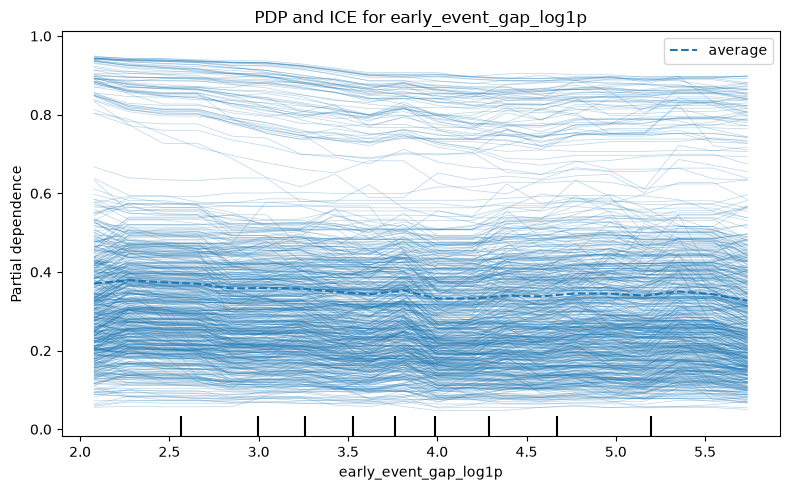

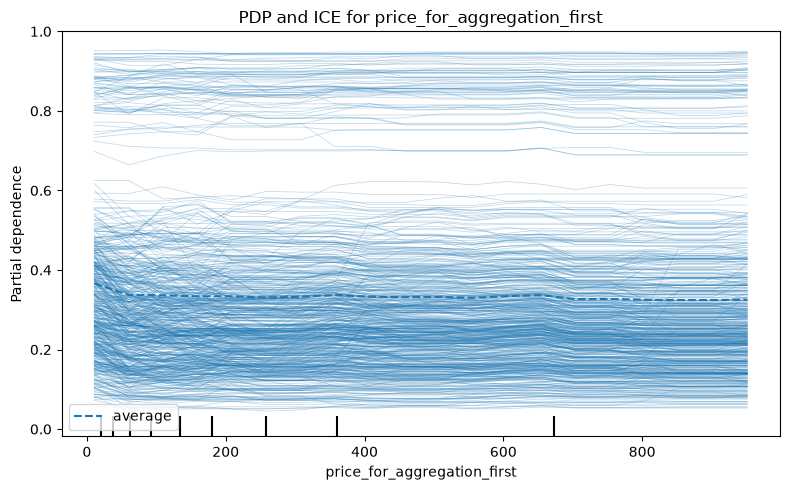

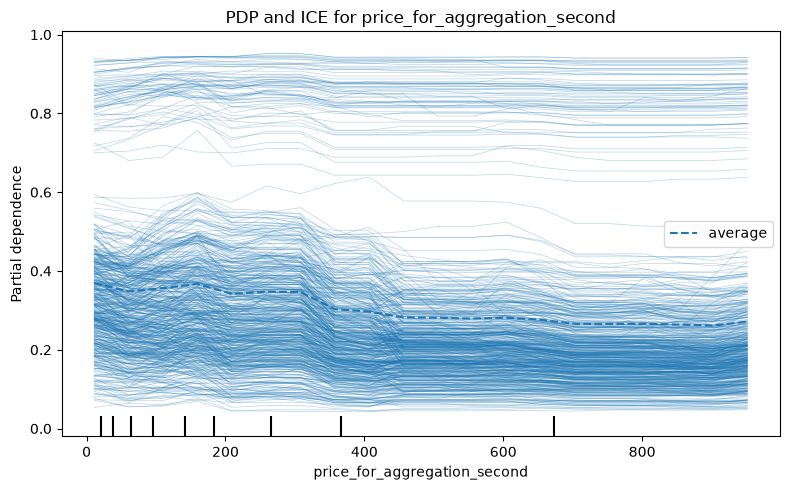

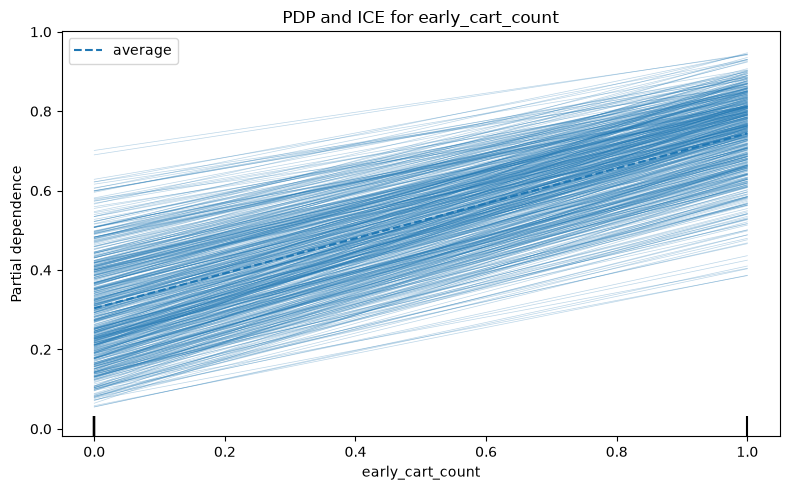

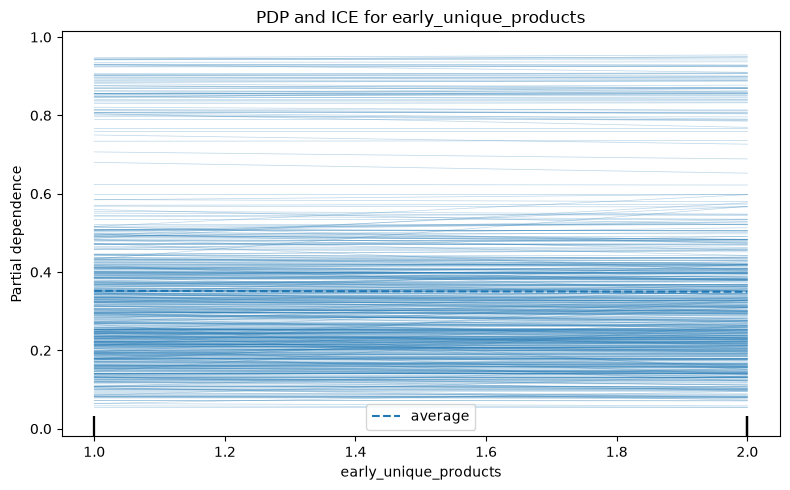

PDP/ICE explainability outputs:


,feature,explanation_type,status,chart_path
0,early_event_gap_log1p,PDP and ICE,Completed,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
1,price_for_aggregation_first,PDP and ICE,Completed,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
2,price_for_aggregation_second,PDP and ICE,Completed,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
3,early_cart_count,PDP and ICE,Completed,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
4,early_unique_products,PDP and ICE,Completed,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...


PDP/ICE summary path:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_pdp_ice_explainability_summary.csv


In [14]:
# Cell 11: PDP and ICE Explainability - Clean Robust Version

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*",
    category=UserWarning
)

# Select interpretable numeric features for PDP/ICE.
pdp_ice_features = [
    "early_event_gap_log1p",
    "price_for_aggregation_first",
    "price_for_aggregation_second",
    "early_cart_count",
    "early_unique_products"
]

pdp_ice_features = [
    feature
    for feature in pdp_ice_features
    if feature in final_model_metadata["retained_raw_features"]
]

PDP_SAMPLE_SIZE = min(3000, len(test_audit_data))

pdp_sample = (
    test_audit_data
    .sample(
        n=PDP_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .copy()
)

X_pdp = pdp_sample[final_model_metadata["retained_raw_features"]].copy()

# Important fix:
# Convert numeric features to float, not integer.
# Newer scikit-learn PDP can raise errors on integer numeric columns.
for feature in final_model_metadata["numeric_features"]:
    if feature in X_pdp.columns:
        X_pdp[feature] = (
            pd.to_numeric(
                X_pdp[feature],
                errors="coerce"
            )
            .astype(float)
        )

for feature in final_model_metadata["categorical_features"]:
    if feature in X_pdp.columns:
        X_pdp[feature] = (
            X_pdp[feature]
            .astype("string")
            .fillna("unknown")
        )

pdp_ice_outputs = []

for feature in pdp_ice_features:
    chart_path = (
        REPORTS_FOLDER
        / f"step5_pdp_ice_{feature}.png"
    )

    try:
        fig, ax = plt.subplots(figsize=(8, 5))

        PartialDependenceDisplay.from_estimator(
            estimator=final_model_pipeline,
            X=X_pdp,
            features=[feature],
            kind="both",
            subsample=0.20,
            random_state=RANDOM_STATE,
            grid_resolution=20,
            response_method="predict_proba",
            ax=ax
        )

        ax.set_title(f"PDP and ICE for {feature}")
        plt.tight_layout()
        plt.savefig(
            chart_path,
            dpi=200,
            bbox_inches="tight"
        )
        plt.show()

        pdp_ice_outputs.append({
            "feature": feature,
            "explanation_type": "PDP and ICE",
            "status": "Completed",
            "chart_path": str(chart_path)
        })

    except Exception as error:
        plt.close()

        pdp_ice_outputs.append({
            "feature": feature,
            "explanation_type": "PDP and ICE",
            "status": f"Skipped due to error: {error}",
            "chart_path": "Not generated"
        })

pdp_ice_summary = pd.DataFrame(pdp_ice_outputs)

PDP_ICE_SUMMARY_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_pdp_ice_explainability_summary.csv"
)

pdp_ice_summary.to_csv(
    PDP_ICE_SUMMARY_PATH,
    index=False
)

print("PDP/ICE explainability outputs:")
display(pdp_ice_summary)

print("PDP/ICE summary path:")
print(PDP_ICE_SUMMARY_PATH)

### PDP and ICE Explainability Results

PDP and ICE plots were generated for five interpretable numeric features: `early_event_gap_log1p`, `price_for_aggregation_first`, `price_for_aggregation_second`, `early_cart_count`, and `early_unique_products`.

The clearest relationship appeared in `early_cart_count`. The model's predicted future-purchase probability increased strongly when a session had at least one cart event within the first two events. This supports the earlier EDA and segment audit findings that early cart behavior is a major purchase-intent signal.

The `early_event_gap_log1p` plot showed a slight decrease in average predicted probability as the gap between the first two events increased, suggesting that faster early-session engagement is associated with higher predicted purchase propensity.

The second observed price showed a more noticeable decline in predicted probability as price increased, while the first observed price had a flatter average effect. The `early_unique_products` plot was also mostly flat, suggesting limited direct average impact.

PDP and ICE plots explain how the model responds to changes in specific features, but they do not prove causality. These plots should be interpreted as model-behavior explanations rather than evidence that a feature directly causes future purchase.

## Ethical AI Limitations and Mitigation Plan

This section documents the main limitations, responsible AI risks, and recommended mitigations for the final model.

# Ethical AI Limitations and Mitigation Plan

In [15]:
# Ethical AI Limitations and Mitigation Plan

ethical_limitations = pd.DataFrame({
    "limitation_area": [
        "No direct demographic attributes",
        "Proxy/segment fairness only",
        "Class imbalance",
        "False negatives",
        "False positives",
        "Behavioral bias toward immediate intent",
        "Temporal generalization",
        "Non-causal interpretation",
        "Model monitoring need"
    ],
    "limitation_or_risk": [
        "The dataset does not contain gender, race, age, income, or other protected demographic attributes.",
        "Fairness analysis can only be performed across available product, time, price, and behavior segments.",
        "Future-purchase sessions are the minority class, making PR-AUC and recall important.",
        "The model misses some actual future purchasers, especially sessions without early cart behavior.",
        "Some non-purchasing sessions are still targeted, which may waste marketing resources.",
        "The model strongly favors sessions with early cart activity and may under-target slower exploratory shoppers.",
        "The dataset covers April 2020 only, so model behavior may change across future months, campaigns, or market conditions.",
        "Feature importance, PDP, ICE, and segment audits show associations in model behavior, not causal effects.",
        "Performance and segment-level behavior may drift after deployment."
    ],
    "recommended_mitigation": [
        "Do not claim formal demographic fairness. Collect sensitive attributes only if legally, ethically, and operationally justified.",
        "Continue segment-level monitoring and avoid using the model for decisions that affect access, eligibility, or service quality.",
        "Use PR-AUC, precision, recall, F1-score, and threshold analysis instead of accuracy alone.",
        "Do not treat unflagged sessions as low-value customers. Use the model for prioritization only.",
        "Avoid aggressive or manipulative targeting. Apply frequency caps and responsible marketing rules.",
        "Consider secondary campaigns for exploratory users or use multiple thresholds for different engagement strategies.",
        "Retrain and validate the model on newer data before production deployment.",
        "Avoid causal claims. Present explanations as predictive associations only.",
        "Monitor performance by segment, recalibrate thresholds, and retrain if drift is detected."
    ]
})

ethical_use_guidelines = pd.DataFrame({
    "guideline": [
        "Recommended use",
        "Not recommended use",
        "Human oversight",
        "Customer treatment",
        "Monitoring",
        "Retraining"
    ],
    "description": [
        "Use the model to prioritize sessions for marketing, remarketing, or customer engagement.",
        "Do not use the model to deny offers, reduce service quality, or permanently label customers as low value.",
        "Business teams should review model outputs and campaign rules before actioning predictions.",
        "Customers should still receive fair access to normal offers, browsing, and service regardless of model score.",
        "Track precision, recall, false positives, false negatives, and segment-level performance over time.",
        "Retrain the model when customer behavior, product catalog, seasonality, or campaign strategy changes."
    ]
})

print("Ethical AI Limitations and Mitigation Plan")
display(ethical_limitations)

print("Responsible Use Guidelines")
display(ethical_use_guidelines)

ETHICAL_LIMITATIONS_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_ethical_limitations_and_mitigations.csv"
)

ETHICAL_USE_GUIDELINES_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_responsible_use_guidelines.csv"
)

ethical_limitations.to_csv(
    ETHICAL_LIMITATIONS_PATH,
    index=False
)

ethical_use_guidelines.to_csv(
    ETHICAL_USE_GUIDELINES_PATH,
    index=False
)

print("Saved ethical AI outputs:")
print(ETHICAL_LIMITATIONS_PATH)
print(ETHICAL_USE_GUIDELINES_PATH)

Ethical AI Limitations and Mitigation Plan


,limitation_area,limitation_or_risk,recommended_mitigation
0,No direct demographic attributes,"The dataset does not contain gender, race, age...",Do not claim formal demographic fairness. Coll...
1,Proxy/segment fairness only,Fairness analysis can only be performed across...,Continue segment-level monitoring and avoid us...
2,Class imbalance,Future-purchase sessions are the minority clas...,"Use PR-AUC, precision, recall, F1-score, and t..."
3,False negatives,The model misses some actual future purchasers...,Do not treat unflagged sessions as low-value c...
4,False positives,Some non-purchasing sessions are still targete...,Avoid aggressive or manipulative targeting. Ap...
5,Behavioral bias toward immediate intent,The model strongly favors sessions with early ...,Consider secondary campaigns for exploratory u...
6,Temporal generalization,"The dataset covers April 2020 only, so model b...",Retrain and validate the model on newer data b...
7,Non-causal interpretation,"Feature importance, PDP, ICE, and segment audi...",Avoid causal claims. Present explanations as p...
8,Model monitoring need,Performance and segment-level behavior may dri...,"Monitor performance by segment, recalibrate th..."


Responsible Use Guidelines


,guideline,description
0,Recommended use,Use the model to prioritize sessions for marke...
1,Not recommended use,"Do not use the model to deny offers, reduce se..."
2,Human oversight,Business teams should review model outputs and...
3,Customer treatment,Customers should still receive fair access to ...
4,Monitoring,"Track precision, recall, false positives, fals..."
5,Retraining,"Retrain the model when customer behavior, prod..."


Saved ethical AI outputs:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_ethical_limitations_and_mitigations.csv
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_responsible_use_guidelines.csv


# Artifact Manifest

In [16]:
# Save Artifact Manifest

STEP5_ARTIFACT_MANIFEST_PATH = (
    PROCESSED_DATA_FOLDER
    / "step5_ethical_ai_artifact_manifest.csv"
)

step5_artifacts = [
    {
        "artifact": "Overall test error and ethical risk summary",
        "path": "Displayed in notebook"
    },
    {
        "artifact": "Sensitive attribute availability review",
        "path": "Displayed in notebook"
    },
    {
        "artifact": "Segment-level model audit results",
        "path": str(SEGMENT_AUDIT_RESULTS_PATH)
    },
    {
        "artifact": "Segment-level model audit summary",
        "path": str(SEGMENT_AUDIT_SUMMARY_PATH)
    },
    {
        "artifact": "High-risk segment groups",
        "path": str(BIAS_RISK_GROUPS_PATH)
    },
    {
        "artifact": "Model explainability summary",
        "path": str(EXPLAINABILITY_SUMMARY_PATH)
    },
    {
        "artifact": "PDP/ICE explainability summary",
        "path": str(PDP_ICE_SUMMARY_PATH)
    },
    {
        "artifact": "Ethical limitations and mitigations",
        "path": str(ETHICAL_LIMITATIONS_PATH)
    },
    {
        "artifact": "Responsible use guidelines",
        "path": str(ETHICAL_USE_GUIDELINES_PATH)
    }
]

# Add PDP/ICE chart paths if available.
if "pdp_ice_summary" in globals():
    for _, row in pdp_ice_summary.iterrows():
        step5_artifacts.append({
            "artifact": f"PDP/ICE chart - {row['feature']}",
            "path": row["chart_path"]
        })

step5_artifact_manifest = pd.DataFrame(step5_artifacts)

step5_artifact_manifest.to_csv(
    STEP5_ARTIFACT_MANIFEST_PATH,
    index=False
)

print("Saved Step 5 Ethical AI artifacts:")
display(step5_artifact_manifest)

print("Step 5 artifact manifest:")
print(STEP5_ARTIFACT_MANIFEST_PATH)

Saved Step 5 Ethical AI artifacts:


,artifact,path
0,Overall test error and ethical risk summary,Displayed in notebook
1,Sensitive attribute availability review,Displayed in notebook
2,Segment-level model audit results,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
3,Segment-level model audit summary,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
4,High-risk segment groups,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
5,Model explainability summary,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
6,PDP/ICE explainability summary,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
7,Ethical limitations and mitigations,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
8,Responsible use guidelines,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...
9,PDP/ICE chart - early_event_gap_log1p,C:\Users\User\OneDrive\Documents\GACAD_DOMINIC...


Step 5 artifact manifest:
C:\Users\User\OneDrive\Documents\GACAD_DOMINIC_Capstone\project_folder\data\processed\step5_ethical_ai_artifact_manifest.csv


# Step 5 Conclusion: Critical Thinking, Ethical AI, and Bias Auditing

Step 5 evaluated the final LightGBM future-purchase prediction model from an ethical AI, explainability, and bias-auditing perspective.

The first finding was that the dataset does not contain direct sensitive demographic attributes such as gender, race, age, income, religion, disability status, or socioeconomic status. Because of this, formal demographic fairness metrics such as demographic parity, equalized odds, and disparate impact across protected groups could not be directly calculated. This limitation was documented clearly to avoid making unsupported fairness claims.

Instead, the audit focused on available non-sensitive customer-session segments, including product category, brand, price band, first-event hour, day of week, early cart behavior, and early event-gap behavior. These segment-level audits do not prove demographic fairness, but they help identify uneven model behavior across business and behavioral contexts.

The overall test error review showed that the final model targeted 1,489 out of 13,920 test sessions, or 10.70% of the test set. At the selected threshold of 0.65, the model achieved precision of 61.38%, recall of 48.96%, and F1-score of 0.5447. The model correctly identified 914 future-purchase sessions but missed 953 actual future-purchase sessions.

The main ethical risk is that false negatives may cause some future purchasers to be missed by targeted interventions. This is especially important for sessions without early cart behavior, where the model showed a high false negative rate. Therefore, unflagged sessions should not be treated as low-value customers.

The segment-level audit showed that the model strongly favors sessions with early cart activity and faster early-session engagement. This makes business sense because early cart behavior is a strong purchase-intent signal, but it also means the model may under-target slower, exploratory, or comparison-shopping customers. Product-category, brand, price-band, and event-gap segments also showed differences in prediction rates and error rates.

Model explainability was performed using LightGBM feature importance and PDP/ICE plots. The most important features included `early_event_gap_log1p`, first and second observed prices, brand, category, and time-based features. PDP/ICE analysis showed that early cart activity strongly increases predicted purchase probability, while longer event gaps and higher second observed prices generally reduce predicted probability. These explanations describe model behavior, not causal relationships.

Several responsible AI limitations were documented, including lack of demographic attributes, class imbalance, false positives, false negatives, behavioral bias toward immediate intent, temporal generalization risk, non-causal interpretation, and the need for ongoing model monitoring.

The recommended use of the model is as a prioritization tool for marketing, remarketing, or customer engagement. It should not be used to deny offers, reduce service quality, or permanently classify customers as low value. Business users should apply human oversight, responsible campaign rules, monitoring, and periodic retraining before any production deployment.

The Step 5 deliverable was completed successfully: a Bias & Fairness Analysis section supported by explainability, limitations, segment-level auditing, ethical risk review, and mitigation recommendations.